In [ ]:
from AutoEncoderObjects import EntropyLimitedAutoencoder, MSSSIMLoss, NLPDLoss, AutoEncodeData
from torch.nn import MSELoss

import pickle
import torch

from LoadingDefault import LoadAudiosTest
import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import Audio
from preprocessing import Reconstruction, adapt

c:\Users\jpeir\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [2]:
with open("DEF MODELS/" + "metadatos_modelos.pkl", "rb") as f:
    lista_cargada = pickle.load(f)
    
mse_songs = EntropyLimitedAutoencoder()
nlpd_songs = EntropyLimitedAutoencoder()
msssim_songs = EntropyLimitedAutoencoder()

mse_noise = EntropyLimitedAutoencoder()
nlpd_noise = EntropyLimitedAutoencoder()
msssim_noise = EntropyLimitedAutoencoder()

mse_songs.load_state_dict(torch.load("DEF MODELS/MSE-songs.pth", map_location=torch.device('cpu')))
nlpd_songs.load_state_dict(torch.load("DEF MODELS/NLPD-songs.pth", map_location=torch.device('cpu')))
msssim_songs.load_state_dict(torch.load("DEF MODELS/MSSSIM-songs.pth", map_location=torch.device('cpu')))

mse_noise.load_state_dict(torch.load("DEF MODELS/MSE-noise.pth", map_location=torch.device('cpu')))
nlpd_noise.load_state_dict(torch.load("DEF MODELS/NLPD-noise.pth", map_location=torch.device('cpu')))
msssim_noise.load_state_dict(torch.load("DEF MODELS/MSSSIM-noise.pth", map_location=torch.device('cpu')))

<All keys matched successfully>

In [3]:
XX, metadata = LoadAudiosTest(limit=30)
XX = adapt(XX)

c:\Users\jpeir\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchaudio\functional\functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (256) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


In [5]:
mse_prove = AutoEncodeData(mse_songs, XX)

In [ ]:
mse_error = MSELoss()
float(mse_error(mse_prove, XX))

0.004890001378953457

In [6]:
numer_error = []
for modelized in (mse_songs, nlpd_songs, msssim_songs, mse_noise, nlpd_noise, msssim_noise):
    resulted = AutoEncodeData(modelized, XX)
    for loss_f in (MSELoss, NLPDLoss, MSSSIMLoss):
        criterion = loss_f()
        numer_error.append(float(criterion(resulted, XX)))

In [ ]:
list_song_noise = ["SONG"] * 9 + ["NOISE"] * 9
list_mse_nlpd_msssim = (["MSE"] * 3 + ["NLPD"] * 3 + ["MSSSIM"] * 3)*2
list_metric_test = ["MSE","NLPD","MSSSIM"] * 6

['MSE',
 'MSE',
 'MSE',
 'NLPD',
 'NLPD',
 'NLPD',
 'MSSSIM',
 'MSSSIM',
 'MSSSIM',
 'MSE',
 'MSE',
 'MSE',
 'NLPD',
 'NLPD',
 'NLPD',
 'MSSSIM',
 'MSSSIM',
 'MSSSIM']

In [ ]:
df = pd.DataFrame({
    "Training Data": list_song_noise,
    "Loss": list_mse_nlpd_msssim,
    "Test Metric": list_metric_test,
    "Value error": numer_error
})

print(df)

# df = df.sort_values(by='Metric Test', key=lambda x: pd.Categorical(x, categories=["MSE","NLPD"], ordered=True))
df = df.pivot(index=("Dataframe train",'Metric train'), columns='Metric Test', values='Value error')
df = df[['MSE','NLPD',"MSSSIM"]]

df = df.sort_values(
    by=["Dataframe train", "Metric train"], 
    ascending=[False, True],  
    key=lambda x: x if x.name != "Metric train" else pd.Categorical(x, categories=["MSE", "NLPD"], ordered=True)
)

df

   Dataframe train Metric train Metric Test  Value error
0             SONG          MSE         MSE     0.009164
1             SONG          MSE        NLPD  1480.788086
2             SONG          MSE      MSSSIM     0.085817
3             SONG         NLPD         MSE     0.006210
4             SONG         NLPD        NLPD  1343.725830
5             SONG         NLPD      MSSSIM     0.076967
6             SONG       MSSSIM         MSE     0.008737
7             SONG       MSSSIM        NLPD  1585.378174
8             SONG       MSSSIM      MSSSIM     0.041370
9            NOISE          MSE         MSE     0.073186
10           NOISE          MSE        NLPD  3784.045410
11           NOISE          MSE      MSSSIM     0.426205
12           NOISE         NLPD         MSE     0.043504
13           NOISE         NLPD        NLPD  2923.176514
14           NOISE         NLPD      MSSSIM     0.316238
15           NOISE       MSSSIM         MSE     0.036189
16           NOISE       MSSSIM

Metric Test                        MSE         NLPD    MSSSIM
Dataframe train Metric train                                 
SONG            MSE           0.009164  1480.788086  0.085817
                NLPD          0.006210  1343.725830  0.076967
                MSSSIM        0.008737  1585.378174  0.041370
NOISE           MSE           0.073186  3784.045410  0.426205
                NLPD          0.043504  2923.176514  0.316238
                MSSSIM        0.036189  2602.726318  0.240125

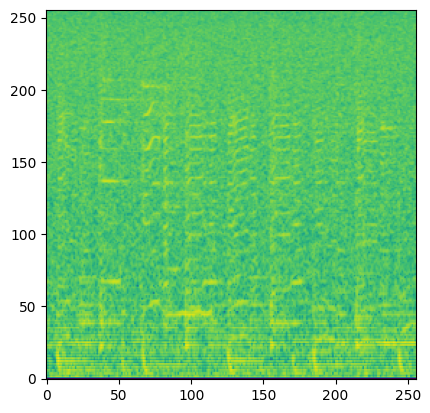

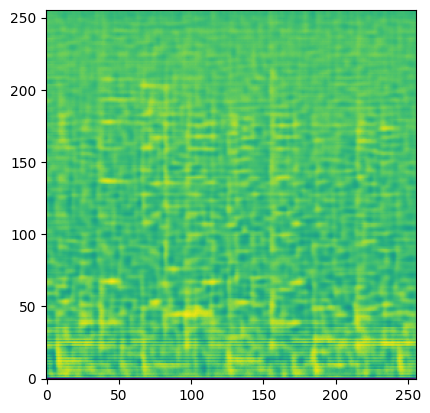

In [ ]:
plt.imshow(XX[5].detach().numpy(),origin='lower')
plt.show()

plt.imshow(mse_prove[5][0].detach().numpy(),origin='lower')
plt.show()

In [ ]:
reconstruction = Reconstruction(XX[5], maxi=metadata[5]["maximum"], mini=metadata[5]["minimum"])
Audio(reconstruction.detach().numpy(), rate=16000)

c:\Users\jpeir\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchaudio\functional\functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (256) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


In [ ]:
reconstruction_rebuild = Reconstruction(mse_prove[5][0], maxi=metadata[5]["maximum"], mini=metadata[5]["minimum"])
Audio(reconstruction_rebuild.detach().numpy(), rate=16000)